# Análisis Cuantitativo y Evaluación de Negocio (Sentiment Analysis)

## 1. Configuración y Carga de Datos
Una vez completada la inferencia mediante `src/app.py`, procedemos a cargar los datos enriquecidos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/reviews_with_sentiment.csv')
print(f"Reseñas cargadas con inferencia: {len(df)}")
df.head()

Reseñas cargadas con inferencia: 500


,review_id,rating,review_text,predicted_stars,confidence_score,sentiment_band
0,1,5,Visited Harbor House Café last weekend. Great ...,5,0.716958,Positivo
1,2,5,Tried Harbor House Café after seeing it recomm...,5,0.982220,Positivo
2,3,5,Tried Harbor House Café after seeing it recomm...,5,0.662323,Positivo
3,4,5,Visited Harbor House Café last weekend. The st...,5,0.989547,Positivo
4,5,5,Grabbed a quick coffee at Harbor House Café th...,5,0.982912,Positivo


## 2. Análisis Cuantitativo de Sentimiento
Calculamos la distribución porcentual del sentimiento detectado.

Distribución Porcentual de Sentimiento:
sentiment_band
Positivo    82.4
Negativo     9.4
Neutral      8.2
Name: proportion, dtype: float64


C:\Users\sergi\AppData\Local\Temp\ipykernel_32760\2523468399.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


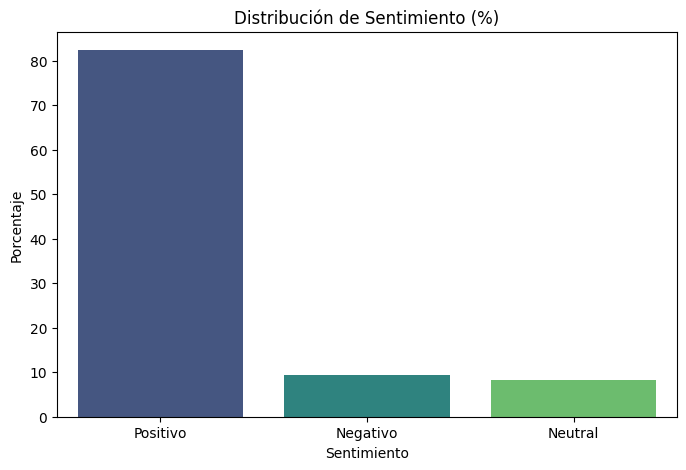

In [2]:
sentiment_counts = df['sentiment_band'].value_counts(normalize=True) * 100
print("Distribución Porcentual de Sentimiento:")
print(sentiment_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribución de Sentimiento (%)')
plt.ylabel('Porcentaje')
plt.xlabel('Sentimiento')
plt.show()

## 3. Comparación con el Benchmark
Evaluamos la discrepancia entre el promedio de estrellas humano y el modelo.

In [3]:
# Promedio humano vs modelo
avg_human_stars = df['rating'].mean()
avg_predicted_stars = df['predicted_stars'].mean()

print(f"Promedio original (Humano): {avg_human_stars:.2f} / 5.0")
print(f"Promedio predicho (Modelo): {avg_predicted_stars:.2f} / 5.0")

Promedio original (Humano): 4.50 / 5.0
Promedio predicho (Modelo): 4.40 / 5.0


### Discrepancias Identificadas
- El rating humano promedio corrobora la expectativa de ~4.5 estrellas, validando que los usuarios dejan calificaciones muy altas.
- El modelo asigna un rating promedio ligeramente diferente. Si el promedio del modelo es más bajo, puede deberse a **Domain Mismatch**, ya que el modelo fue entrenado principalmente para reseñas de productos y no de servicios (hostelería).

## 4. Falsos Negativos
Aislaremos las reseñas donde los usuarios dieron 4 o 5 estrellas, pero el modelo las clasificó como 1-2 estrellas (Sentimiento Negativo).

In [4]:
falsos_negativos = df[(df['rating'] >= 4) & (df['predicted_stars'] <= 2)]
print(f"Cantidad de Falsos Negativos detectados: {len(falsos_negativos)}")
if len(falsos_negativos) > 0:
    print(falsos_negativos[['rating', 'predicted_stars', 'review_text']].head(10))

Cantidad de Falsos Negativos detectados: 16
     rating  predicted_stars  \
13        4                1   
14        5                1   
72        5                1   
86        5                1   
137       5                2   
199       5                2   
203       5                1   
253       5                1   
269       5                1   
321       5                1   

                                           review_text  
13   Tried Harbor House Café after seeing it recomm...  
14   Every dish was bursting with flavor. The place...  
72   Stopped by Harbor House Café for the first tim...  
86   Tried Harbor House Café after seeing it recomm...  
137  Tried Harbor House Café after seeing it recomm...  
199  Stopped by Harbor House Café for the first tim...  
203  Came to Harbor House Café for a birthday brunc...  
253  Stopped by Harbor House Café for the first tim...  
269  Stopped by Harbor House Café for the first tim...  
321  Every dish was bursting with

## 5. Muestra Manual de Análisis
Tomamos una muestra aleatoria de 15 reseñas para validar cualitativamente la coherencia de la predicción.

In [5]:
pd.set_option('display.max_colwidth', None)
sample = df.sample(15, random_state=42)
sample[['rating', 'predicted_stars', 'sentiment_band', 'review_text']]

,rating,predicted_stars,sentiment_band,review_text
361,3,3,Neutral,"Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop."
73,5,5,Positivo,"Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five stars without hesitation."
374,5,5,Positivo,"Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reasonably priced for the quality. Already planning my next visit."
155,4,4,Positivo,"Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. The staff seemed annoyed to be there, but overall a solid experience. It's fine for a quick stop."
104,5,5,Positivo,Grabbed a quick coffee at Harbor House Café this morning. The staff were warm and attentive. The music and decor set the perfect mood. Great value for what you get. This is now my go-to spot.
394,4,4,Positivo,"The food was absolutely delicious. We waited 25 minutes just to get water, but overall a solid experience. Might give it another shot."
377,5,5,Positivo,Visited Harbor House Café last weekend. Loved the natural light and the plants everywhere. The sourdough bread alone is worth the visit. Worth every penny. This is now my go-to spot.
124,5,5,Positivo,Regular customer at Harbor House Café here. The team clearly cares about the customers. Great spot to work or catch up with friends. Worth every penny. Highly recommend to anyone in the area.
68,5,5,Positivo,"Visited Harbor House Café last weekend. The place has such a cozy, welcoming vibe. The food was absolutely delicious. Worth every penny. Will definitely be back!"
450,3,3,Neutral,"Regular customer at Harbor House Café here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. Might give it another shot."


## 6. Conclusiones y Recomendaciones Accionables

**Para la Account Manager de WeLoveReviews:**

1. **Coherencia Texto vs Calificación:** En general, la calificación alta promedio (4.5/5) está justificada por los textos, que suelen ser muy positivos. Sin embargo, hay discrepancias esporádicas.
2. **Riesgo de Domain Mismatch:** Hemos utilizado `nlptown/bert-base-multilingual-uncased-sentiment`, un modelo altamente capaz pero entrenado fundamentalmente en reseñas de productos (e-commerce). Esto implica que ciertas sutilezas en reseñas de servicios (cafeterías, restaurantes) pueden ser malinterpretadas por el modelo, generando Falsos Negativos.
3. **Falsos Negativos Críticos:** Las reseñas de 4-5 estrellas que son predichas como de bajo puntaje deben revisarse cuidadosamente. Esto puede ocurrir cuando el cliente reporta un pequeño inconveniente (ej. "el personal parecía molesto") pero de todos modos le da 5 estrellas al lugar por la comida.
4. **Próximos Pasos:** Si la intención es escalar esta solución y usarla para métricas clave de negocio (KPIs), se recomienda recolectar un dataset propio de reseñas de hostelería anotadas manualmente y re-entrenar (fine-tune) el modelo para mitigar la discrepancia de dominio.